In [ ]:
from IPython.display import HTML
HTML("<style>.jp-Cell { max-width: 1000px; margin: 0 auto; }</style>")

# Origination Data Analysis

## Business Problem
Lenders approve loans largely on a borrower's credit score at application. That single number hides the **direction** the borrower's credit is moving: two applicants with a 700 score can carry very different risk if one is stable and the other is sliding.

This analysis of **135,000 loans (Jan-2022 to Dec-2024, ~3,750 per month)** asks:
1. Is origination volume stable?
2. What share of new borrowers already show credit deterioration at origination?
3. Do they default more, and by enough to justify changes to underwriting or pricing?

## Approach
- Grouped borrowers by pre-origination credit behaviour:
  - **Stable**: consistent credit profile
  - **Gradual Decline**: steady weakening over several months
  - **Sudden Shock**: sharp recent drop (e.g. a missed payment or a utilisation spike)
  - **Credit Seeking**: high number of recent credit enquiries
- Tracked the monthly mix of these patterns and compared their **12-month default rates**.

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates 

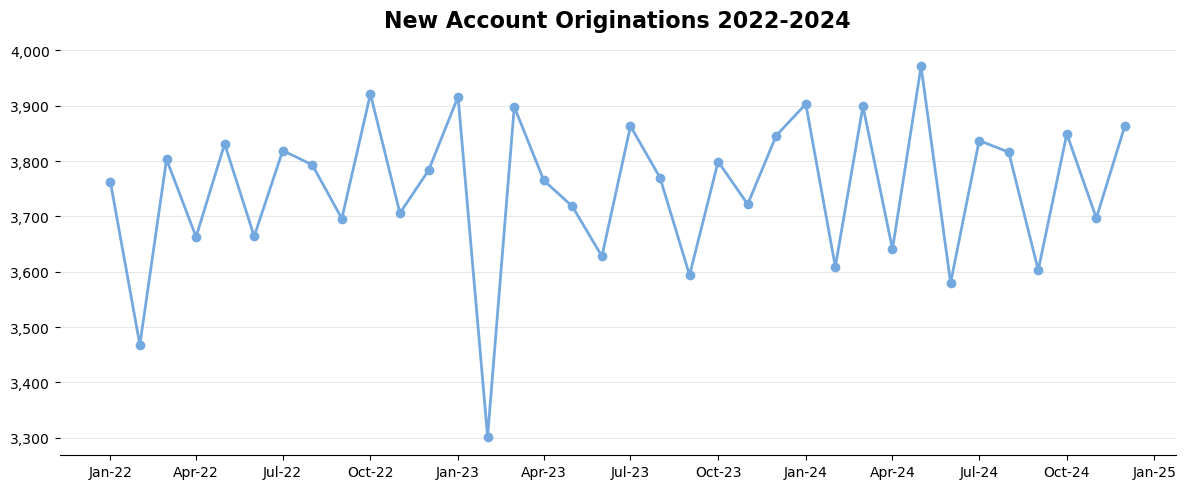

In [69]:
from matplotlib.ticker import PercentFormatter, StrMethodFormatter

# --- shared chart style ---
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 16,
    "axes.titlepad": 15,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,
    "grid.alpha": 0.3,
    "legend.frameon": False,
})
BLUE = "#74A9E0"

# --- data ---
orig = pd.read_csv("origination_data-2.csv")
# monthly_perf = pd.read_csv("monthly_performance-2.csv")   # not used here; uncomment if needed
orig["application_date"] = pd.to_datetime(orig["application_date"])

monthly_counts = orig.groupby(orig["application_date"].dt.to_period("M"))["customer_id"].count()
monthly_counts.index = monthly_counts.index.to_timestamp()

# --- line chart ---
plt.figure()
plt.plot(monthly_counts.index, monthly_counts.values, marker="o", color=BLUE, linewidth=2)
plt.title("New Account Originations 2022-2024")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
plt.gca().yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()

- Monthly originations stayed stable at roughly **3,600–3,950 accounts**, with no long-term upward or downward trend. 
- The sharp dip in **Feb-23 (~3,300)** stands out and should be checked for a seasonal, policy or data-capture cause

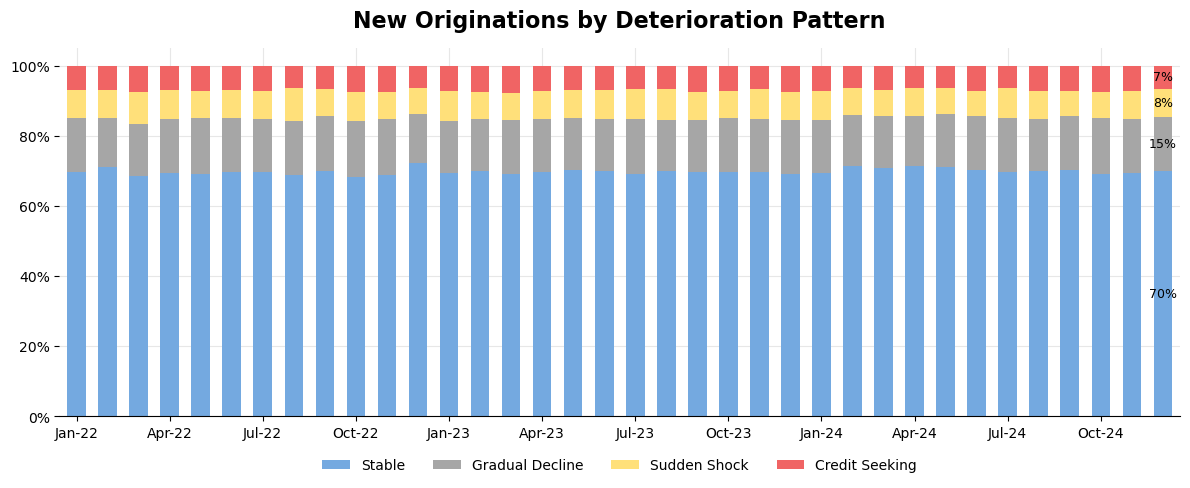

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

df = pd.read_excel("New Originations by Deterioration Pattern.xlsx", index_col="Application Date")
df.index = pd.to_datetime(df.index, format="%b-%y").strftime("%b-%y")

colors = ["#74A9E0", "#A6A6A6", "#FFE07A", "#F06464"]
ax = df.plot(kind="bar", stacked=True, figsize=(12, 5), width=0.6, color=colors)

ax.set_title("New Originations by Deterioration Pattern", fontsize=16, pad=15)
ax.set_xlabel("")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xticks(range(0, len(df), 3), df.index[::3], rotation=0)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.08), frameon=False)

# % labels next to the last bar
for c in ax.containers:
    ax.bar_label(c, labels=[""] * (len(df) - 1) + [f"{c.datavalues[-1]:.0%}"], label_type="center", padding=0, fontsize=9)

plt.tight_layout()
plt.show()

- **70%** of new originations come from consumers with stable credit score.
- **~23%** of new loans show early deterioration signals, and these default at nearly 2 times the rate of stable borrowers (11.7% vs 6.5%).

## Key Findings
- Volume is steady (~3,600–3,950/month), apart from a one-off dip in Feb-23.
- **~70%** of new borrowers are Stable; **~23%** already show early deterioration.
- Deteriorating borrowers default at **~1.8x** the rate of Stable ones (**11.7% vs 6.5%**).
- Credit Seeking borrowers (**6.1%**) do *not* default more than Stable ones, so enquiry
  count on its own is a weak risk signal.

## Business Recommendations
- Add **credit trend features** (score change and utilisation change over 6–12 months) to the
  underwriting model, not just point-in-time scores.
- Apply **risk-based pricing or lower limits** to Gradual Decline and Sudden Shock applicants.
- Set up **early-warning monitoring** after booking, so the collections team can reach
  at-risk borrowers early.
- Reconsider policies that penalise credit enquiries alone, which may be turning away good customers

In [78]:
import subprocess

nb = "Origination Data Analysis"
subprocess.run(["jupyter", "nbconvert", "--to", "html", "--no-input", f"{nb}.ipynb"], check=True)

css = "<style>body { max-width: 1100px; margin: 0 auto !important; padding: 0 24px; }</style></head>"
html = open(f"{nb}.html", encoding="utf-8").read()
open(f"{nb}.html", "w", encoding="utf-8").write(html.replace("</head>", css, 1));